In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [8]:
target = pd.read_csv('Plant_1_Generation_Data.csv')
features = pd.read_csv('Plant_1_Weather_Sensor_Data.csv')

print(f'target  :\n {target.iloc[0:5]}')
print(f'features  :\n  {features.iloc[0:5]}')

target  :
           DATE_TIME  PLANT_ID       SOURCE_KEY  DC_POWER  AC_POWER  \
0  15-05-2020 00:00   4135001  1BY6WEcLGh8j5v7       0.0       0.0   
1  15-05-2020 00:00   4135001  1IF53ai7Xc0U56Y       0.0       0.0   
2  15-05-2020 00:00   4135001  3PZuoBAID5Wc2HD       0.0       0.0   
3  15-05-2020 00:00   4135001  7JYdWkrLSPkdwr4       0.0       0.0   
4  15-05-2020 00:00   4135001  McdE0feGgRqW7Ca       0.0       0.0   

   DAILY_YIELD  TOTAL_YIELD  
0          0.0    6259559.0  
1          0.0    6183645.0  
2          0.0    6987759.0  
3          0.0    7602960.0  
4          0.0    7158964.0  
features  :
               DATE_TIME  PLANT_ID       SOURCE_KEY  AMBIENT_TEMPERATURE  \
0  2020-05-15 00:00:00   4135001  HmiyD2TTLFNqkNe            25.184316   
1  2020-05-15 00:15:00   4135001  HmiyD2TTLFNqkNe            25.084589   
2  2020-05-15 00:30:00   4135001  HmiyD2TTLFNqkNe            24.935753   
3  2020-05-15 00:45:00   4135001  HmiyD2TTLFNqkNe            24.846130   
4  2

In [9]:
# Convert to date time objects, formats are different
target['DATE_TIME'] = pd.to_datetime(target['DATE_TIME'],dayfirst=True)
features['DATE_TIME'] = pd.to_datetime(features['DATE_TIME'])

target_avg = target.groupby('DATE_TIME')['AC_POWER'].mean().reset_index()
features_modified = features.drop(columns=['PLANT_ID','SOURCE_KEY'])
merge = pd.merge(features_modified,target_avg,on='DATE_TIME',how='inner')

print(f'combined dataset: \n {merge.iloc[0:10]}')

combined dataset: 
             DATE_TIME  AMBIENT_TEMPERATURE  MODULE_TEMPERATURE  IRRADIATION  \
0 2020-05-15 00:00:00            25.184316           22.857507          0.0   
1 2020-05-15 00:15:00            25.084589           22.761668          0.0   
2 2020-05-15 00:30:00            24.935753           22.592306          0.0   
3 2020-05-15 00:45:00            24.846130           22.360852          0.0   
4 2020-05-15 01:00:00            24.621525           22.165423          0.0   
5 2020-05-15 01:15:00            24.536092           21.968571          0.0   
6 2020-05-15 01:30:00            24.638674           22.352926          0.0   
7 2020-05-15 01:45:00            24.873022           23.160919          0.0   
8 2020-05-15 02:00:00            24.936930           23.026113          0.0   
9 2020-05-15 02:15:00            25.012248           23.343229          0.0   

   AC_POWER  
0       0.0  
1       0.0  
2       0.0  
3       0.0  
4       0.0  
5       0.0  
6       0.0 

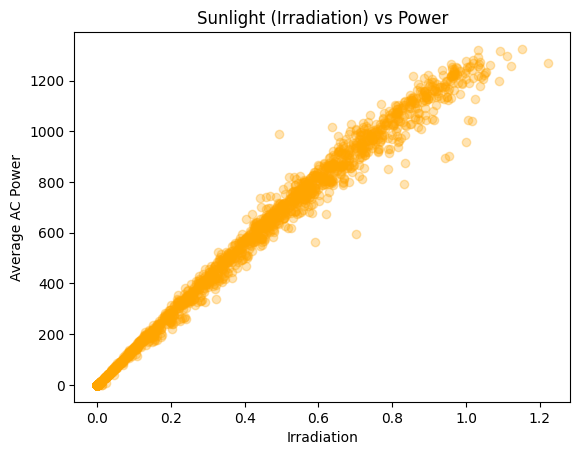

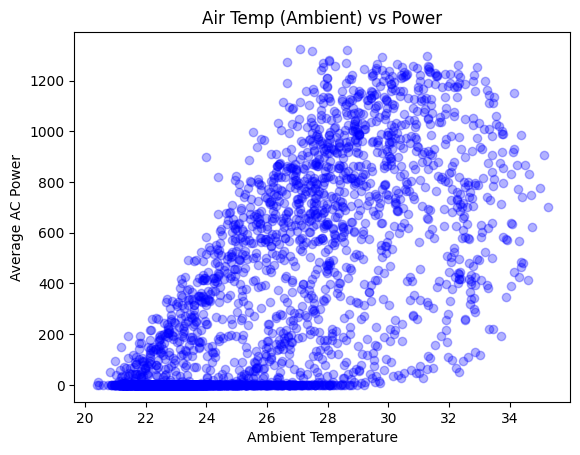

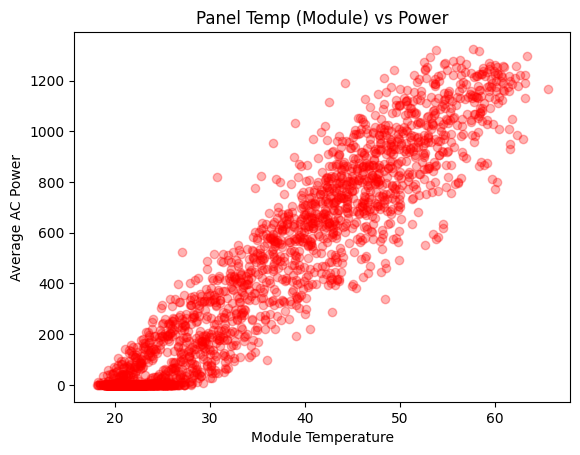

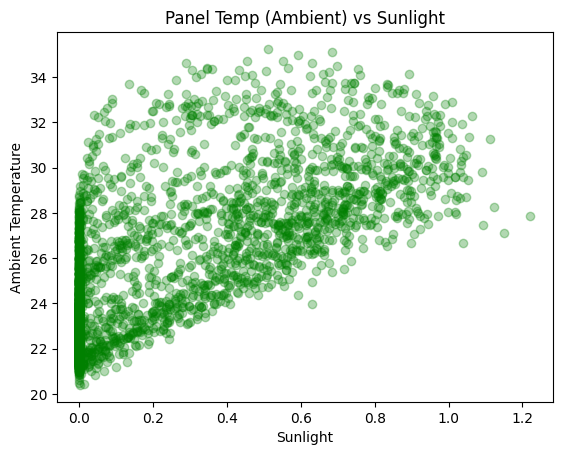

In [10]:
# Visualizing features against the target to understand relevancy and make regression model
# plot 1
plt.scatter(merge['IRRADIATION'], merge['AC_POWER'], color='orange', alpha=0.3)

plt.title('Sunlight (Irradiation) vs Power')
plt.xlabel('Irradiation')
plt.ylabel('Average AC Power')

plt.show()

# plot 2
plt.scatter(merge['AMBIENT_TEMPERATURE'], merge['AC_POWER'], color='blue', alpha=0.3)

plt.title('Air Temp (Ambient) vs Power')
plt.xlabel('Ambient Temperature')
plt.ylabel('Average AC Power')

plt.show()

# plot 3
plt.scatter(merge['MODULE_TEMPERATURE'], merge['AC_POWER'], color='red', alpha=0.3)

plt.title('Panel Temp (Module) vs Power')
plt.xlabel('Module Temperature')
plt.ylabel('Average AC Power')

plt.show()

# plot 4 - feature engineering support
plt.scatter(merge['IRRADIATION'], merge['AMBIENT_TEMPERATURE'], color='green', alpha=0.3)

plt.title('Panel Temp (Ambient) vs Sunlight')
plt.xlabel('Sunlight')
plt.ylabel('Ambient Temperature')

plt.show()

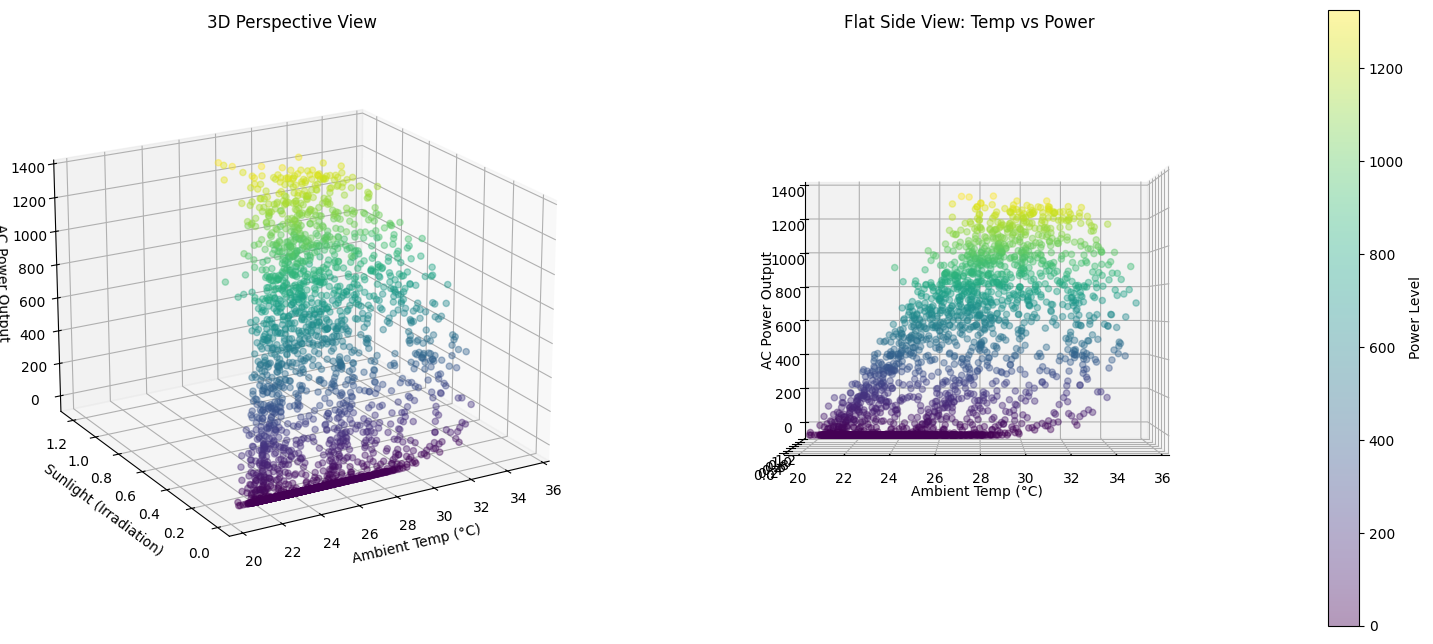

In [11]:
# Create a wider figure to fit two plots
fig = plt.figure(figsize=(20, 8))

# --- Plot 1: Your 3D Perspective ---
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
scatter1 = ax1.scatter(merge['AMBIENT_TEMPERATURE'], merge['IRRADIATION'], merge['AC_POWER'], 
                       c=merge['AC_POWER'], cmap='viridis', alpha=0.4, s=20)
ax1.view_init(elev=20, azim=-120) # Meeting point corner in front
ax1.set_xlabel('Ambient Temp (°C)')
ax1.set_ylabel('Sunlight (Irradiation)')
ax1.set_zlabel('AC Power Output')
ax1.set_title('3D Perspective View')

# --- Plot 2: The Flat Side View (Temp vs Power) ---
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
scatter2 = ax2.scatter(merge['AMBIENT_TEMPERATURE'], merge['IRRADIATION'], merge['AC_POWER'], 
                       c=merge['AC_POWER'], cmap='viridis', alpha=0.4, s=20)

# elev=0 flattens the view; azim=-90 hides the Sunlight depth
ax2.view_init(elev=0, azim=-90)

ax2.set_xlabel('Ambient Temp (°C)')
ax2.set_ylabel('') # Collapse Sunlight axis label
ax2.set_zlabel('AC Power Output')
ax2.set_title('Flat Side View: Temp vs Power')

# Add a shared colorbar
fig.colorbar(scatter1, ax=[ax1, ax2], label='Power Level')

plt.show()

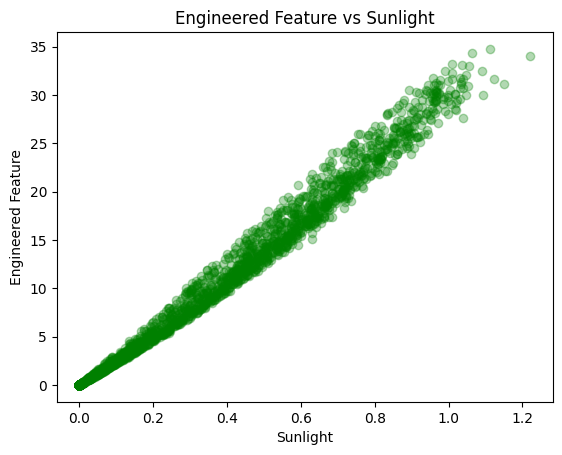

In [12]:
plt.scatter(merge['IRRADIATION'], merge['AMBIENT_TEMPERATURE'] * merge['IRRADIATION'], color='green', alpha=0.3)

plt.title('Engineered Feature vs Sunlight')
plt.xlabel('Sunlight')
plt.ylabel('Engineered Feature')

plt.show()

Max Power Reference: 1325.01 kW


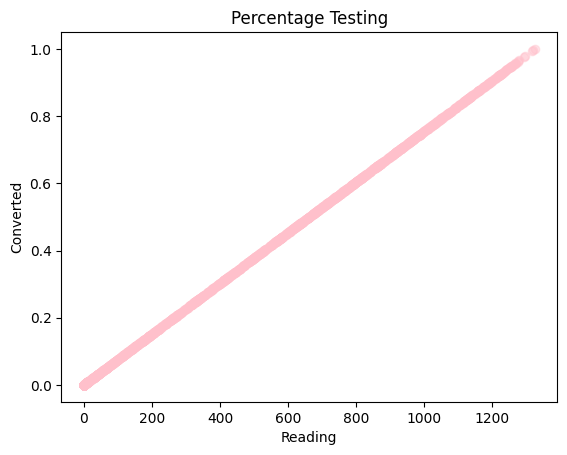

In [13]:
# need to scale the target, to be a percentage from AC current, take the recorder max as 100%
# 1. Extract the "Peak Performance" of the plant
max_power = merge['AC_POWER'].max()

# 2. Create your normalized target variable (y)
merge['POWER_PCT'] = merge['AC_POWER'] / max_power

print(f"Max Power Reference: {max_power:.2f} kW")

plt.scatter(merge['AC_POWER'], merge['POWER_PCT'], color='pink', alpha=0.4)
plt.title("Percentage Testing")
plt.xlabel("Reading")
plt.ylabel("Converted")
plt.show()

In [14]:
# feature scaling
# 1. Engineering the feature
merge['ENGINEERED'] = merge['IRRADIATION'] * merge['AMBIENT_TEMPERATURE']

# 2. Calculating Mean (mu)
mu = merge['ENGINEERED'].mean()

# 3. Calculating Standard Deviation (sigma)
# Note: You must sum the squared differences to get a single number!
sigma = merge['ENGINEERED'].std() 

# 4. Correct Normalization
merge['SCALED_ENGINEERED'] = (merge['ENGINEERED'] - mu) / sigma

# feature 2
mu2 = merge['IRRADIATION'].mean()
sigma2 = merge['IRRADIATION'].std()
merge['SCALED_IRRADIATION'] = (merge['IRRADIATION'] - mu2) / sigma2

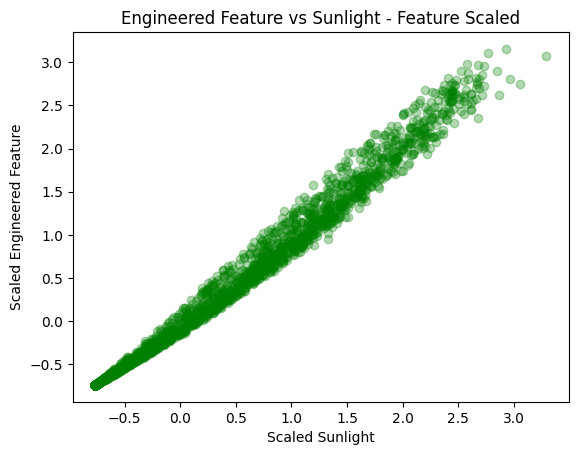

In [15]:
plt.scatter(merge['SCALED_IRRADIATION'], merge['SCALED_ENGINEERED'], color='green', alpha=0.3)

plt.title('Engineered Feature vs Sunlight - Feature Scaled')
plt.xlabel('Scaled Sunlight')
plt.ylabel('Scaled Engineered Feature')

plt.show()

In [16]:
print("Data Count : %d " % merge.shape[0])

Data Count : 3157 


In [17]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [2]:
X = merge[['SCALED_IRRADIATION','SCALED_ENGINEERED']]
y = merge['POWER_PCT']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# data are ready now

# 1. Initialize
model = LinearRegression()

# 2. Train (This solves the math directly)
model.fit(X_train, y_train)

# 3. Access your parameters
w = model.coef_      # This will be an array [w1, w2]
b = model.intercept_ # This is your single value for b

print(f"Model: y = ({w[0]:.2f})x1 + ({w[1]:.2f})x2 + {b:.2f}")

NameError: name 'merge' is not defined

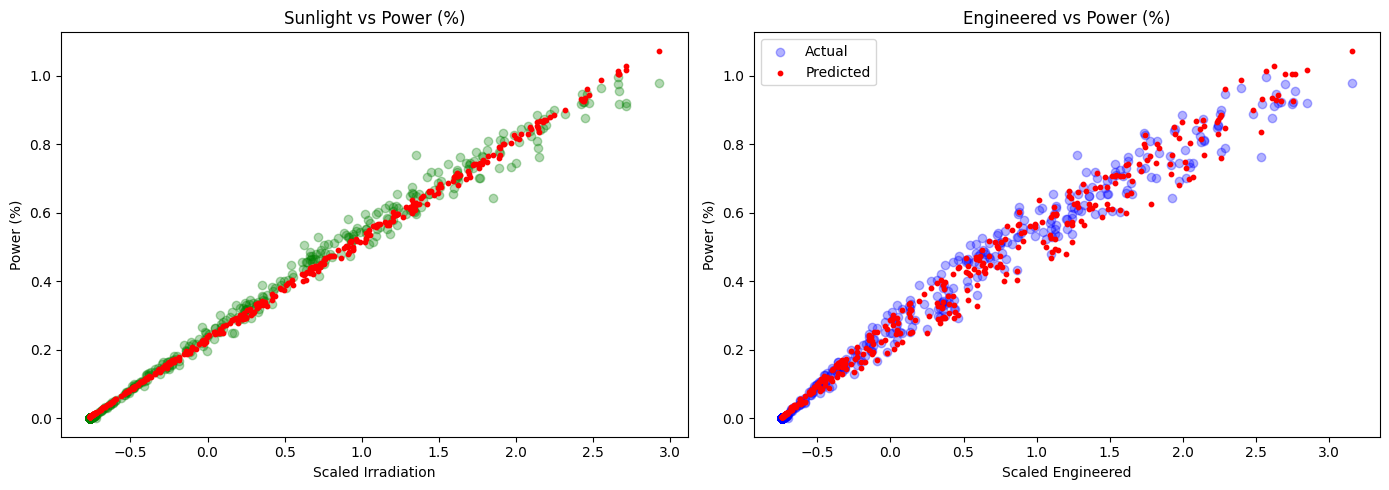

In [21]:
# Generate predictions
y_pred = model.predict(X_test)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Sunlight vs Power (%)
ax1.scatter(X_test['SCALED_IRRADIATION'], y_test, color='green', alpha=0.3, label='Actual')
ax1.scatter(X_test['SCALED_IRRADIATION'], y_pred, color='red', s=10, label='Predicted')
ax1.set_title('Sunlight vs Power (%)')
ax1.set_xlabel('Scaled Irradiation')
ax1.set_ylabel('Power (%)')

# Plot 2: Engineered Feature vs Power (%)
ax2.scatter(X_test['SCALED_ENGINEERED'], y_test, color='blue', alpha=0.3, label='Actual')
ax2.scatter(X_test['SCALED_ENGINEERED'], y_pred, color='red', s=10, label='Predicted')
ax2.set_title('Engineered vs Power (%)')
ax2.set_xlabel('Scaled Engineered')
ax2.set_ylabel('Power (%)')

plt.legend()
plt.tight_layout()
plt.show()

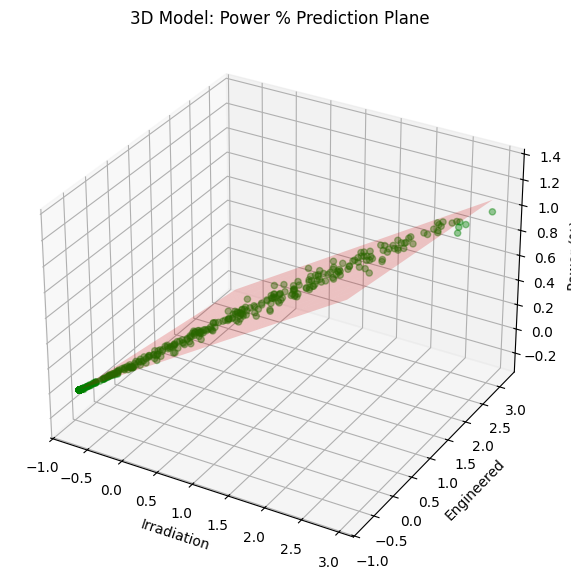

In [22]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# 1. Scatter plot of actual test data
ax.scatter(X_test['SCALED_IRRADIATION'], X_test['SCALED_ENGINEERED'], y_test, color='green', alpha=0.4)

# 2. Create the Plane mesh
x1_range = np.linspace(X_test['SCALED_IRRADIATION'].min(), X_test['SCALED_IRRADIATION'].max(), 10)
x2_range = np.linspace(X_test['SCALED_ENGINEERED'].min(), X_test['SCALED_ENGINEERED'].max(), 10)
X1, X2 = np.meshgrid(x1_range, x2_range)

# 3. Apply the model formula: y = w1*x1 + w2*x2 + b
Z = model.coef_[0] * X1 + model.coef_[1] * X2 + model.intercept_

# 4. Plot the surface
ax.plot_surface(X1, X2, Z, color='red', alpha=0.2)

ax.set_xlabel('Irradiation')
ax.set_ylabel('Engineered')
ax.set_zlabel('Power (%)')
plt.title('3D Model: Power % Prediction Plane')
plt.show()

--- Model Accuracy Report ---
R^2 Score (Variance explained): 0.9939
Mean Absolute Error (Average error): 0.01%
Root Mean Squared Error (Penalty for big misses): 0.02%


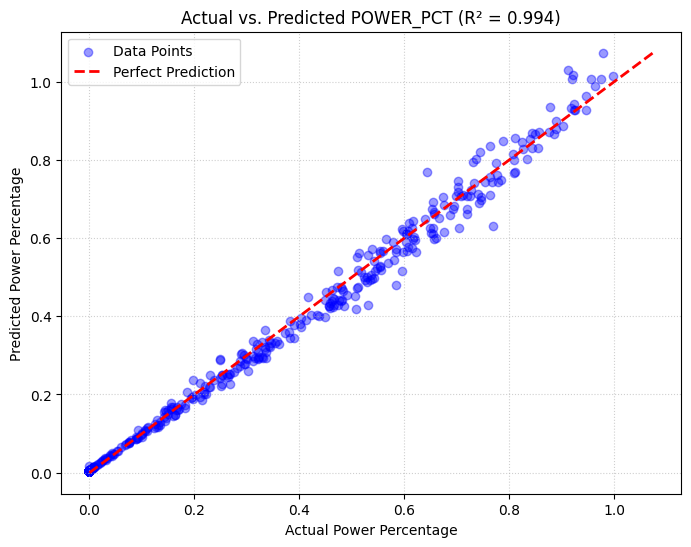

In [24]:
from sklearn import metrics

# 1. Generate predictions using the test set
y_pred = model.predict(X_test)

# 2. Calculate Key Accuracy Metrics
r2 = metrics.r2_score(y_test, y_pred)
mae = metrics.mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(metrics.mean_squared_error(y_test, y_pred))

print(f"--- Model Accuracy Report ---")
print(f"R^2 Score (Variance explained): {r2:.4f}")
print(f"Mean Absolute Error (Average error): {mae:.2f}%")
print(f"Root Mean Squared Error (Penalty for big misses): {rmse:.2f}%")

# 3. Create the Accuracy Plot (Actual vs Predicted)
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.4, label='Data Points')

# Draw the 'Perfect Prediction' line (a 45-degree diagonal)
max_val = max(y_test.max(), y_pred.max())
min_val = min(y_test.min(), y_pred.min())
plt.plot([min_val, max_val], [min_val, max_val], color='red', lw=2, linestyle='--', label='Perfect Prediction')

plt.title(f'Actual vs. Predicted POWER_PCT (R² = {r2:.3f})')
plt.xlabel('Actual Power Percentage')
plt.ylabel('Predicted Power Percentage')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [1]:
import joblib

# Save the trained model to a file
joblib.dump(model, 'solar_model.pkl')

NameError: name 'model' is not defined